<a href="https://colab.research.google.com/github/amanpoonia/Research_project_Prof.Nour/blob/main/Chartisme_v02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PART 1: Returns at t conditional on t-1**

`(t-1,t)`


**PART 2: Returns at t conditional on t-1 and t-2**

`(t-2,t-1,t)`

*EURUSD*

# PART 1

In [25]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_14176/1154363021.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


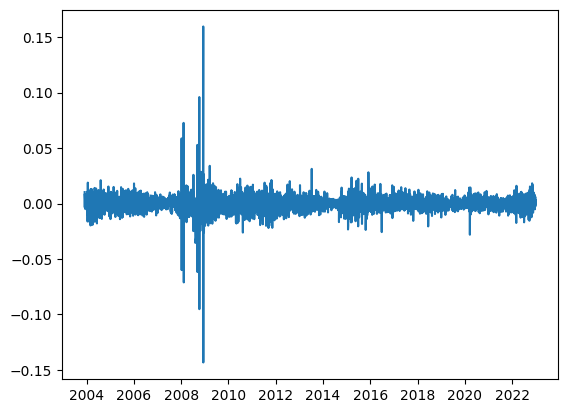

In [26]:
#tickerlist = ['EURUSD=X','^GSPC']
ticker = ['EURUSD=X']
end_date = dt.datetime(2022,12,31)
start_date = dt.datetime(2003,12,1)

#download all the data for the period, for the tickers listed
data = yf.download(ticker, start_date, end_date)

#prices as data downloaded has many columns Close, High, Low, Volumne
#log returns
prices = data['Close']
pct_change = prices.pct_change()
log_returns = np.log(1+pct_change)

#plotting the log_returns
plt.plot(log_returns)

In [27]:
#defining the quantiles for different states
#<30% data in lower : State = -1
#30-70% data in middle : State = 0
#>70% data in upper : State = 1

lower = log_returns.quantile(0.30)
upper = log_returns.quantile(0.70)

In [28]:
#defining the categories
log_returns_categorized = log_returns.copy()
conditions = [
    log_returns_categorized['EURUSD=X'] < lower['EURUSD=X'],
    log_returns_categorized['EURUSD=X'] > upper['EURUSD=X']
]
choices = [-1, 1]
log_returns_categorized['category'] = np.select(conditions, choices, default=0)
log_returns_categorized = log_returns_categorized.dropna()

In [29]:
#labelling the categories
'''
    (-1,-1) -> 0
    (-1,0) -> 1
    (-1,1) -> 2
    (0,-1) -> 3
    (0,0) -> 4
    (0,1) -> 5
    (1,-1) -> 6
    (1,0) -> 7
    (1,1) -> 8
'''

df = log_returns_categorized.copy()

df['pattern'] = (
    (df['category'].shift(1) + 1) * 3 +
    (df['category'] + 1)
)
df = df.dropna()

In [30]:
# days corresponding to each pattern
count = df['pattern'].value_counts().sort_index()

In [31]:
# probability attached with each pattern
probs = count / count.groupby(count.index // 3).transform('sum')
prob_states = probs*100

In [32]:
#3X3 PROBABILITY TRANSITION MATRIX
counts = count.sort_index().values.reshape(3, 3)
probs = counts / counts.sum(axis=1, keepdims=True)

transition_table = pd.DataFrame(
    probs*100,
    index=[-1, 0, 1],   # previous state
    columns=[-1, 0, 1]  # current state
)

print(round(transition_table,2))

       -1      0      1
-1  28.69  38.38  32.93
 0  28.79  41.06  30.15
 1  32.95  40.23  26.82


In [35]:
#3X3 RETURNS MATRIX
sums = df.groupby('pattern')['EURUSD=X'].mean().reindex(range(9), fill_value=0)
sums *= 100
matrix = sums.values.reshape(3, 3)
table_3x3 = pd.DataFrame(
    matrix,
    index=[-1, 0, 1],   # previous category
    columns=[-1, 0, 1]  # current category
)

print(round(table_3x3,3))

       -1      0      1
-1 -0.699  0.007  0.710
 0 -0.618  0.002  0.620
 1 -0.736  0.004  0.684


------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_14176/1365581454.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


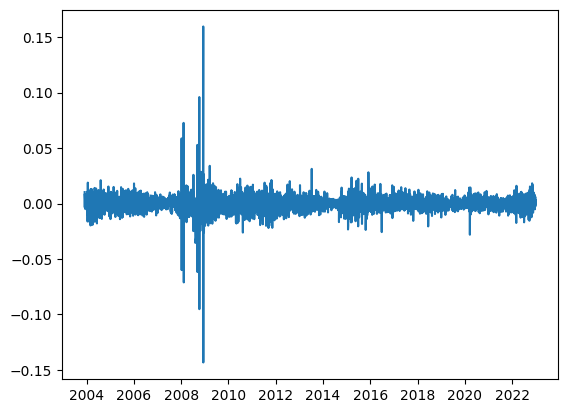

In [3]:
#tickerlist = ['EURUSD=X','GSPC']
ticker = ['EURUSD=X']
end_date = dt.datetime(2022,12,31)
start_date = dt.datetime(2003,12,1)

#download all the data for the period, for the tickers listed
data = yf.download(ticker, start_date, end_date)

#prices as data downloaded has many columns Close, High, Low, Volumne
#log returns
prices = data['Close']
pct_change = prices.pct_change()
log_returns = np.log(1+pct_change)

#plotting the log_returns
plt.plot(log_returns)

#defining the quantiles for different states
#<30% data in lower : State = -1
#30-70% data in middle : State = 0
#>70% data in upper : State = 1

lower = log_returns.quantile(0.30)
upper = log_returns.quantile(0.70)

#defining the categories
log_returns_categorized = log_returns.copy()
conditions = [
    log_returns_categorized['EURUSD=X'] < lower['EURUSD=X'],
    log_returns_categorized['EURUSD=X'] > upper['EURUSD=X']
]
choices = [-1, 1]
log_returns_categorized['category'] = np.select(conditions, choices, default=0)
log_returns_categorized = log_returns_categorized.dropna()

In [4]:
#labelling the categories
#This is different than lag of just 1, as there are two lags considered, total number of cases would be 27.
'''
    (-1,-1,-1) -> 0
    (-1,-1,0) -> 1
    (-1,-1,1) -> 2
    (-1,0,-1) -> 3
    (-1,0,0) -> 4
    (-1,0,1) -> 5
    (-1,1,-1) -> 6
    (-1,1,0) -> 7
    (-1,1,1) -> 8
    (0,-1,-1) -> 9
    (0,-1,0) -> 10
    (0,-1,1) -> 11
    (0,0,-1) -> 12
    (0,0,0) -> 13
    (0,0,1) -> 14
    (0,1,-1) -> 15
    (0,1,0) -> 16
    (0,1,1) -> 17
    (1,-1,-1) -> 18
    (1,-1,0) -> 19
    (1,-1,1) -> 20
    (1,0,-1) -> 21
    (1,0,0) -> 22
    (1,0,1) -> 23
    (1,1,-1) -> 24
    (1,1,0) -> 25
    (1,1,1) -> 26

'''

df = log_returns_categorized.copy()

df['pattern'] = (
    (df['category'].shift(2) + 1) * 9 +
    (df['category'].shift(1) + 1) * 3 +
    (df['category'] + 1)
)
df = df.dropna()

In [5]:
# days corresponding to each pattern
count = df['pattern'].value_counts().sort_index()

# probability attached with each pattern
probs = count / count.groupby(count.index // 3).transform('sum')
prob_states = probs*100

In [7]:
#9X3 PROBABILITY TRANSITION MATRIX
counts = count.sort_index().values.reshape(9, 3)
probs = counts / counts.sum(axis=1, keepdims=True)


In [8]:
probs

array([[0.2629108 , 0.38732394, 0.34976526],
       [0.31052632, 0.39649123, 0.29298246],
       [0.32310838, 0.42331288, 0.25357873],
       [0.29473684, 0.42105263, 0.28421053],
       [0.27060271, 0.42927429, 0.300123  ],
       [0.31040268, 0.41275168, 0.27684564],
       [0.29856851, 0.33742331, 0.36400818],
       [0.28978224, 0.39865997, 0.31155779],
       [0.36683417, 0.36180905, 0.27135678]])

In [37]:
transition_table = pd.DataFrame(
    probs*100,
    index=['-1,-1', '-1,0', '-1,1', '0,-1', '0,0', '0,1', '1,-1', '1,0', '1,1'],   # previous state
    columns=[-1, 0, 1]  # current state
)
print(round(transition_table,2))

ValueError: Shape of passed values is (3, 3), indices imply (9, 3)

In [36]:
#9X3 RETURNS MATRIX
sums = df.groupby('pattern')['EURUSD=X'].mean().reindex(range(27), fill_value=0)
sums *= 100
matrix = sums.values.reshape(9, 3)
table_9x3 = pd.DataFrame(
    matrix,
    index=['-1,-1', '-1,0', '-1,1', '0,-1', '0,0', '0,1', '1,-1', '1,0', '1,1'],   # previous category
    columns=[-1, 0, 1]  # current category
)

print(round(table_9x3,3))

          -1      0      1
-1,-1 -0.699  0.007  0.710
-1,0  -0.618  0.002  0.620
-1,1  -0.736  0.004  0.684
0,-1   0.000  0.000  0.000
0,0    0.000  0.000  0.000
0,1    0.000  0.000  0.000
1,-1   0.000  0.000  0.000
1,0    0.000  0.000  0.000
1,1    0.000  0.000  0.000


In [6]:
prob_states

,count
pattern,
0.0,26.291080
1.0,38.732394
2.0,34.976526
3.0,31.052632
4.0,39.649123
5.0,29.298246
6.0,32.310838
7.0,42.331288
8.0,25.357873


In [59]:
count

,count
pattern,
0.0,112
1.0,165
2.0,149
3.0,177
4.0,226
5.0,167
6.0,158
7.0,207
8.0,124


Ticker,EURUSD=X,category,pattern
Date,,,
2003-12-04,-0.003473,-1,24.0
2003-12-05,0.008736,1,20.0
2003-12-08,0.002709,1,8.0
2003-12-09,0.002447,0,25.0
2003-12-10,-0.004827,-1,21.0
2003-12-11,0.002710,1,11.0
2003-12-12,0.004484,1,8.0
2003-12-15,0.003333,1,26.0
2003-12-16,0.000160,0,25.0


In [16]:
data

Price          Close                   High                    Low  \
Ticker      EURUSD=X        ^GSPC  EURUSD=X        ^GSPC  EURUSD=X   
Date                                                                 
2003-12-01  1.196501  1070.119995  1.204007  1070.469971  1.194401   
2003-12-02  1.208897  1066.619995  1.210903  1071.219971  1.194600   
2003-12-03  1.212298  1064.729980  1.213003  1074.300049  1.207700   
2003-12-04  1.208094  1069.719971  1.214403  1070.369995  1.204398   
2003-12-05  1.218695  1061.500000  1.219096  1069.719971  1.206593   
...              ...          ...       ...          ...       ...   
2022-12-26  1.066780          NaN  1.063717          NaN  1.060895   
2022-12-27  1.064022  3829.250000  1.066900  3846.649902  1.061244   
2022-12-28  1.063717  3783.219971  1.067430  3848.320068  1.061391   
2022-12-29  1.062925  3849.280029  1.067019  3858.189941  1.061233   
2022-12-30  1.066075  3839.500000  1.069793  3839.850098  1.063920   

Price                        Open                Volume                
Ticker            ^GSPC  EURUSD=X        ^GSPC EURUSD=X         ^GSPC  
Date                                                                   
2003-12-01  1058.199951  1.203398  1058.199951      0.0  1.375000e+09  
2003-12-02  1065.219971  1.196101  1070.119995      0.0  1.383200e+09  
2003-12-03  1064.630005  1.209000  1066.619995      0.0  1.441700e+09  
2003-12-04  1063.150024  1.212004  1064.729980      0.0  1.463100e+09  
2003-12-05  1060.089966  1.207802  1069.719971      0.0  1.265900e+09  
...                 ...       ...          ...      ...           ...  
2022-12-26          NaN  1.066780          NaN      0.0           NaN  
2022-12-27  3813.219971  1.064022  3843.340088      0.0  3.030300e+09  
2022-12-28  3780.780029  1.063717  3829.560059      0.0  3.083520e+09  
2022-12-29  3805.449951  1.062925  3805.449951      0.0  3.003680e+09  
2022-12-30  3800.340088  1.066075  3829.060059      0.0  2.979870e+09  

[4980 rows x 10 columns]

In [17]:
prices

Ticker,EURUSD=X,^GSPC
Date,,
2003-12-01,1.196501,1070.119995
2003-12-02,1.208897,1066.619995
2003-12-03,1.212298,1064.729980
2003-12-04,1.208094,1069.719971
2003-12-05,1.218695,1061.500000
...,...,...
2022-12-26,1.066780,NaN
2022-12-27,1.064022,3829.250000
2022-12-28,1.063717,3783.219971


In [18]:
log_returns

Ticker,EURUSD=X,^GSPC
Date,,
2003-12-01,NaN,NaN
2003-12-02,0.010307,-0.003276
2003-12-03,0.002809,-0.001774
2003-12-04,-0.003473,0.004676
2003-12-05,0.008736,-0.007714
...,...,...
2022-12-26,0.006062,0.000000
2022-12-27,-0.002589,-0.004058
2022-12-28,-0.000287,-0.012093
